##### Chatbot that uses the saved memories to answer the query

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# ----------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------
store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")  # namespace

store.put(user_details, "profile_1", {"data": "Name: Nitish"})
store.put(user_details, "profile_2", {"data": "Profession: Teaches AI on YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [4]:
# ----------------------------
# 2) System Prompt template (your prompt)
# ----------------------------

SYSTEM_PROMPT_TEMPLATE = """
You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    - Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    - Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    - Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    - Greetings and transitions
    - Help or guidance tailored to tools and frameworks the user uses
    - Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [5]:
# model
model = ChatGoogleGenerativeAI(model = "gemini-3-flash-preview", temperature=0.7)

In [6]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = model.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

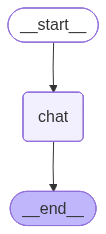

In [7]:
# ----------------------------
# 3) Build graph: START -> chat -> END (read-only LTM)
# ----------------------------

builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [8]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)

Nitish, since you teach AI on YouTube, you likely want a clear, punchy way to explain this to your audience.

In simple terms, **Generative AI** is a type of artificial intelligence that can create *new* content—like text, code, images, or audio—instead of just analyzing existing data. While traditional AI is like a critic that tells you if a photo is a cat, Gen AI is the artist that draws a cat from scratch.

It works by learning the patterns and structures of the data it was trained on, allowing it to predict what comes next in a sequence to generate something original.

### Python Example
For your Python-based projects, you can interact with a Gen AI model (like GPT-4) using a few lines of code:

```python
import openai

# A simple call to generate a YouTube video title
response = openai.chat.completions.create(
    model="gpt-4o",
    messages=[{"role": "user", "content": "Suggest a title for a video about building MCP servers in Python."}]
)

print(response.choices[0].message.cont

##### Chatbot that creates the memory on its own based on the convration

"It's like an chatbot that desides if the conversation we had with the user has some useable memory in it or not if yes then it save it in the memory"

In [13]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

import uuid
from typing import TypedDict, List
from pydantic import BaseModel, Field

from dotenv import load_dotenv
load_dotenv()

True

In [14]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [15]:
# ----------------------------
# 2) LLM that decides what to remember (structured output)
# ----------------------------
extractor_llm = ChatGoogleGenerativeAI(model = "gemini-3-flash-preview", temperature=0.7)

In [16]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store")

In [17]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [18]:
# ----------------------------
# 3) Graph: START -> remember -> END
#    (Creates memories, but does NOT use them to answer)
# ----------------------------
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    
    namespace = ("user", user_id, "details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    # Write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

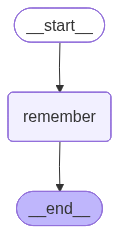

In [19]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [20]:
# ----------------------------
# 4) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is nitish"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [21]:
res = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on youtube"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [22]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [23]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

The user's name is Nitish.
The user teaches AI on YouTube.
The user's favorite programming language is Python.


In [24]:
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is nitish"}]},config)
print("Assistant:", res["messages"][-1].content)
res = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on youtube"}]},config)
print("Assistant:", res["messages"][-1].content)
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

Assistant: Noted.
Assistant: Noted.
Assistant: Noted.
The user's name is Nitish.
The user teaches AI on YouTube.
The user's favorite programming language is Python.
The user's name is Nitish.
Teaches AI on YouTube.
The user's favorite programming language is Python.


##### Chatbot Creating New Memories(without Duplication)

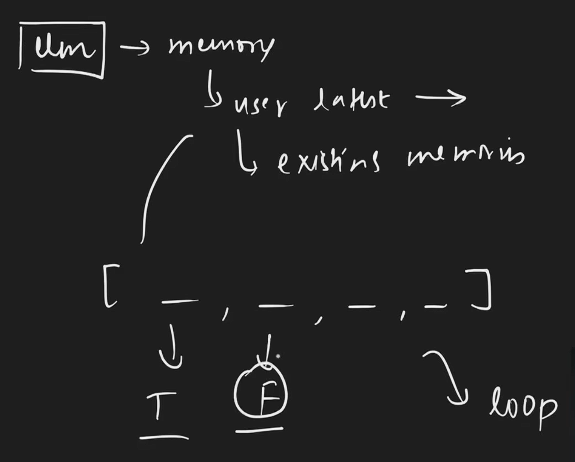

In [52]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [53]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [54]:
# ----------------------------
# 2) LLMs
#    - memory_llm: extracts candidate memories + tells if each is NEW (no duplicate_of needed)
# ----------------------------
memory_llm = ChatGoogleGenerativeAI(model = "gemini-3-flash-preview", temperature=0.7)

In [55]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [56]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [57]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [58]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [59]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

In [60]:
# ----------------------------
# 4) Build graph: START -> chat -> END
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

In [61]:
config = {"configurable": {"user_id": "u1"}}

In [62]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Nitish"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [63]:
# Likely duplicate of the first memory -> is_new should be false -> saved=0
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)


Assistant: Noted.


In [64]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

The user's name is Nitish.
Nitish likes Python for programming.


In [65]:
config = {"configurable": {"user_id": "u1"}}
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Nitish"}]}, config)
print("Assistant:", r1["messages"][-1].content)
# Likely duplicate of the first memory -> is_new should be false -> saved=0
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)

for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

Assistant: Noted.

Assistant: Noted.
The user's name is Nitish.
Nitish likes Python for programming.


##### Chatbot that creates and use memory to answer

In [109]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [110]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [111]:
# ----------------------------
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [123]:
# ----------------------------
# 3) Memory extraction LLM
# ----------------------------
memory_llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash", temperature=0.7)

In [124]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [125]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [126]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [127]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list.
"""

In [128]:
# ----------------------------
# 4) Node 1: remember
# ----------------------------
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # existing memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})

    return {}  # no message change

In [129]:
# ----------------------------
# 5) Chat LLM
# ----------------------------
chat_llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash", temperature=0.7)

In [130]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

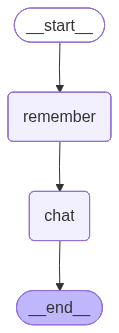

In [131]:
# ----------------------------
# 6) Graph
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [132]:
config = {"configurable": {"user_id": "u1"}}

In [133]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Nitish"}]}, config)
result['messages'][-1].content

"Hello Nitish! It's great to meet you. I've made a note of your name. How can I help you today?\n\nHere are 3 questions you might want to ask:\n1.  What kind of tasks can you help me with, Nitish?\n2.  Can you remember other details about me for future interactions?\n3.  How do I tell you about my projects or preferences?"

In [134]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user's name is Nitish.


In [135]:
result = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on YouTube"}]}, config)
print(result['messages'][-1].content)

That's right, Nitish! I already have that in my memory – you teach AI on YouTube. That's fantastic! It's a great way to share knowledge and help others understand complex topics.

How can I assist you with your AI teaching or YouTube channel today, Nitish?

Here are 3 further questions you might have:
1.  What kind of AI topics do you typically cover on your channel, Nitish?
2.  Are you looking for any tools or resources that could help with your video production or content creation?
3.  Would you like some ideas for new AI topics that are currently trending?


In [136]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user's name is Nitish.
The user teaches AI on YouTube.


In [137]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Hey Nitish! Given your work teaching AI on YouTube, I'm sure you've already got a great grasp on a lot of these concepts, but I'd be happy to explain Generative AI (GenAI) simply for you.

At its core, **Generative AI** is a type of artificial intelligence that can **create new, original content** that has never existed before.

Think of it this way:
*   Most traditional AI is *discriminative* – it's good at **classifying** or **predicting**. For example, identifying if an image contains a cat or a dog, or predicting tomorrow's stock price.
*   **Generative AI**, on the other hand, is *creative*. It doesn't just recognize patterns; it uses those patterns to **generate** entirely new outputs.

It learns from vast amounts of existing data (like text, images, audio, or code) to understand the underlying structures and styles. Then, when given a prompt or a starting point, it uses that learned knowledge to produce something novel and coherent that often looks, sounds, or reads incredibly r

In [138]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user's name is Nitish.
The user teaches AI on YouTube.
